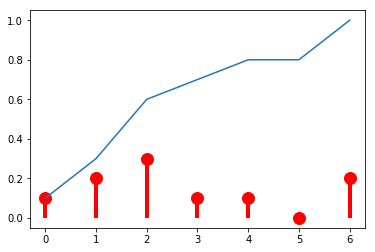

In [1]:
import numpy as np
from scipy import stats
xk = np.arange(7)
pk = (0.1, 0.2, 0.3, 0.1, 0.1, 0.0, 0.2)
custm = stats.rv_discrete(name='custm', values=(xk, pk))

import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(1, 1)
ax.plot(xk, custm.pmf(xk), 'ro', ms=12, mec='r')
ax.plot(xk, custm.cdf(xk),'-')
ax.vlines(xk, 0, custm.pmf(xk), colors='r', lw=4)
plt.show()

In [2]:
R = custm.rvs(size=1000)

(array([  84.,  297.,  575.,  681.,  780., 1000.]),
 array([0, 1, 2, 3, 4, 5, 6]),
 <a list of 6 Patch objects>)

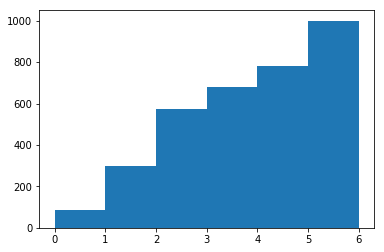

In [3]:
plt.hist(R,bins=[0,1,2,3,4,5,6],cumulative=True)

mass= 2.5521e+13 0.025521


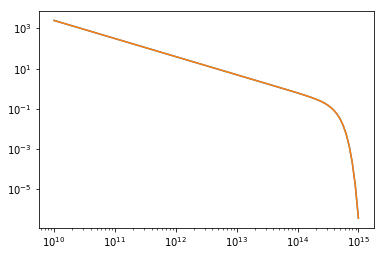

In [4]:
def raddist_moka(x,cvir=5):
    alpha=1.944
    beta=2.75
    return 1.0-(1+alpha*cvir)*x**beta/(1+alpha*cvir*x**2)

def massf(x,mnorm):
    m=x
    A=np.log(10)*10**-3.03
    g=-0.9
    d=12.2715
    zresc=(1.0+0.35)**0.5
    return(zresc*A*(m*mnorm)**g*np.exp(-d*m**3)*mnorm)


x=np.logspace(-5,0,100)
dlogx=np.log10(x[1])-np.log10(x[0])
blog = []
for i in range(len(x)):
    blog.append(10**(np.log10(x[i])-dlogx/2.0))
    
blog.append(10**(np.log10(x[-1])+dlogx/2.0))

#x=np.linspace(1e-5,1,1000)
mnorm=1e15
mf=massf(x,mnorm)
ngen = np.int((np.array([mf[i]*(np.log10(blog[i+1])-np.log10(blog[i])) for i in range(len(mf))]).sum()))
ntot=np.trapz(mf*x*mnorm,x)
print ("mass= %10.4e %f" % (np.float(ntot), np.float(ntot)/np.float(mnorm)))

plt.plot(x*mnorm,mf)

#mnorm=1e13
#mf=massf(x,mnorm)
#ntot=np.trapz(mf*x*mnorm,x)
#print ("mass= %10.4e %f" % (np.float(ntot), np.float(ntot)/np.float(mnorm)))

plt.plot(x*mnorm,mf)
plt.xscale('log')
plt.yscale('log')

# normalized mass function:
kmf=mf.copy()
#ngen=np.int(np.sum(mf))
mf=np.array(mf).astype(float)/np.sum(mf)



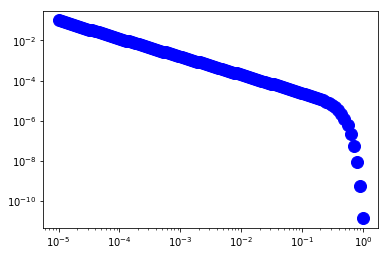

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(1, 1)
#ax.plot(x, mf, 'ro', ms=12, mec='r')

custm = stats.rv_discrete(name='custm', values=(range(len(x)), mf))
ax.plot(x, custm.pmf(range(len(x))), 'bo', ms=12, mec='b')
#ax.vlines(x, 0, custm.pmf(x), colors='r', lw=4)
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()


67
9.4473e+09 2.2606e+13 1268 1.6508e+14   0.1651


'\nmr = []\nfor i in range(ngen):\n    mr.append(10**((np.log10(blog[R[i]+1]) - np.log10(blog[R[i]])) * np.random.random_sample(ngen) + np.log10(blog[R[i]])))\nmr=np.array(mr)*mnorm\nprint ("%10.4e %10.4e" % (mr.min(),mr.max()))\n\nk1,k2,k3=plt.hist(R,bins=range(len(x)))\nplt.xscale(\'log\')\nplt.yscale(\'log\')\ngenerated_masses = x[R]*mnorm\nprint ("%10.4e %10.4e" % (generated_masses.min(),generated_masses.max()))\n'

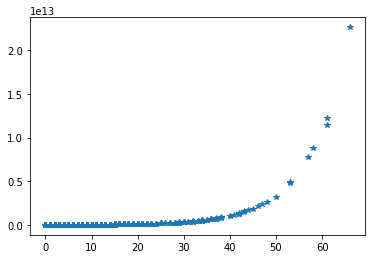

In [6]:
R = custm.rvs(size=ngen)
R_=R+1
rnum = np.random.random_sample(ngen)
print (R_.max())
# subhalo falls in bin R, meaning that its mass is in the range blog[R]-blog[R+1]
mr = [10**((np.log10(blog[R_[i]]) - np.log10(blog[R[i]])) * rnum[i] + np.log10(blog[R[i]])) for i in range(ngen)]
mr=np.array(mr)*mnorm
print ("%10.4e %10.4e %i %10.4e %8.4f" % (mr.min(),mr.max(),ngen,mr.sum(),mr.sum()/mnorm))
plt.plot(R,mr,'*')

"""
mr = []
for i in range(ngen):
    mr.append(10**((np.log10(blog[R[i]+1]) - np.log10(blog[R[i]])) * np.random.random_sample(ngen) + np.log10(blog[R[i]])))
mr=np.array(mr)*mnorm
print ("%10.4e %10.4e" % (mr.min(),mr.max()))

k1,k2,k3=plt.hist(R,bins=range(len(x)))
plt.xscale('log')
plt.yscale('log')
generated_masses = x[R]*mnorm
print ("%10.4e %10.4e" % (generated_masses.min(),generated_masses.max()))
"""

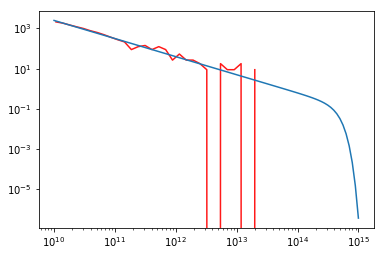

In [7]:
def plot_shmf(ms):
    nbins=30
    dn,b = np.histogram(np.log10(ms),nbins)
    x = (b[1:] + b[:-1])/2.0
    dx = b[1]-b[0]
    dn = dn/dx#/self.mvir[index_max]
    plt.plot(10**x,dn,color='red',linestyle='-',alpha=0.9)
    
plot_shmf(mr)
plt.plot(x*mnorm,kmf,'-')
plt.xscale('log')
plt.yscale('log')

In [8]:
plt.plot(x[0:-1]*mnorm,k1,'-')
plt.plot(x*mnorm,kmf,'-')
plt.xscale('log')
plt.yscale('log')

NameError: name 'k1' is not defined

In [9]:
from scipy import optimize

def generate_radius(rn,cvir,alpha,beta):

    def raddist_cdf(x):
        return 1.0-(1+alpha*cvir)*x**beta/(1+alpha*cvir*x**2) - rn

    root = optimize.brentq(raddist_cdf, 0, 1)
    return root

    
rad=np.logspace(-3,0,1000)
prad = raddist_moka(rad,cvir=5) - rand
plt.plot(rad,prad,'-')

rn_tot = 1000
rn_ = np.random.random_sample(rn_tot)
r = []
alpha=1.944
beta=2.75
for rn in rn_:
    r.append(generate_radius(rn, cvir=5.0, alpha=alpha, beta=beta))

#plt.xscale('log')
#plt.yscale('log')

NameError: name 'rand' is not defined

NameError: name 'r' is not defined

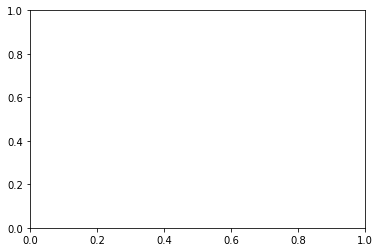

In [10]:
fig, ax = plt.subplots(1, 1)
a,b,c=ax.hist(r, bins=100,cumulative=-1)


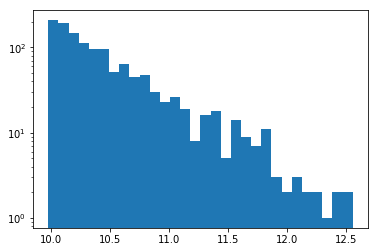

In [11]:
from pyLensLib import subhaloPop
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

kwargs = {
    'zhalo': 0.35,
    'cvir': 5.0,
    'mmin':1e10,
    'halo_ell2d': 0.4,
    'halo_pa': np.pi
}

sh = subhaloPop.subhaloPop(**kwargs)

plt.hist(np.log10(sh.mr),bins=30)
plt.yscale('log')

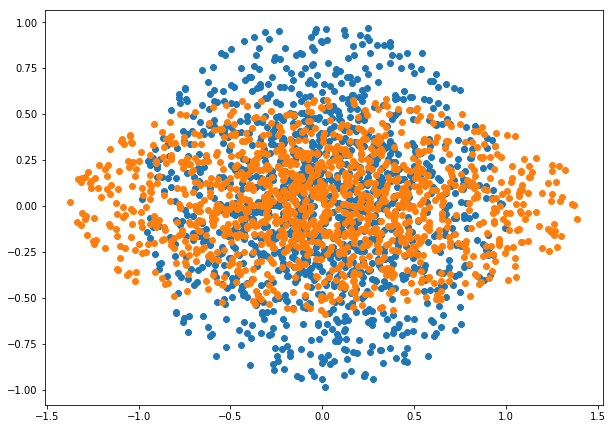

In [2]:
x=sh.r*np.cos(sh.pa)
y=sh.r*np.sin(sh.pa)

fig,ax = plt.subplots(1,1,figsize=(10,10))
ax.plot(x,y,'o')
ax.plot(sh.x,sh.y,'o')
ax.set_aspect('equal')



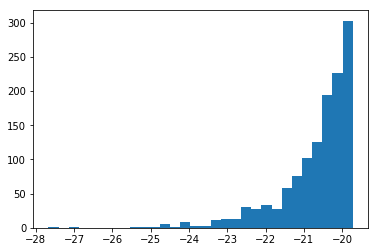

In [3]:
h,b,c=plt.hist(sh.Mag,bins=30)



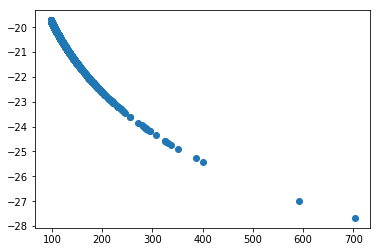

In [4]:
plt.plot(sh.sigma,sh.Mag,'o')

In [5]:
print (-2.5*np.log10((220.0/sh.sh_msigma_sigma0)**())

SyntaxError: unexpected EOF while parsing (<ipython-input-5-5f3a82eb1eab>, line 1)

1.7241622926832973
Distance to the lens: 1259.0836
Lens concentration:   3.5115
Lens mass: 1000000000000000.0000
conversion scale 1Mpc=x arcsec: 163.8214
163.82137507884693
1042 10734


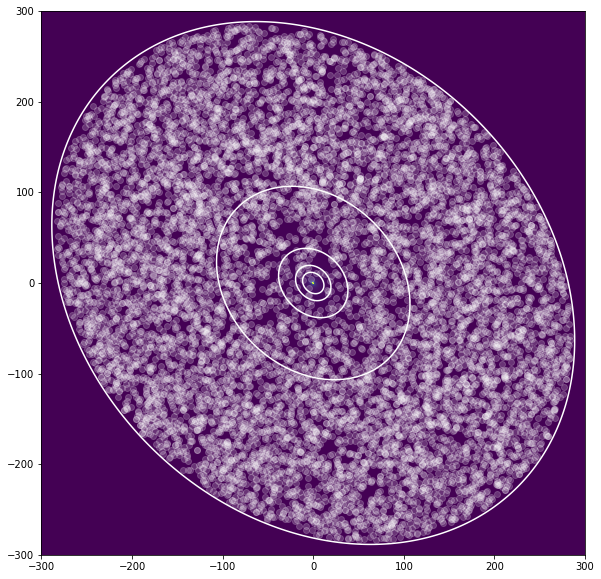

In [97]:
from pyLensLib import nfwell
from pyLensLib import piemd
from pyLensLib import subhaloPop
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
q=0.8
kwargs_nfw = {'q': q, 'x1': 0.0, 'x2': 0.0, 'pa': np.pi/4.0, 'zl': 0.5}
kwargs_piemd = {'q': q, 'x1': 0.0, 'x2': 0.0, 'pa': np.pi/4.0, 'zl': 0.5, 'sigma0': 1200.0, 'theta_t': 1000.0}
ell=(1.0-q)/(1.0+q)
nl = nfwell.nfwell(**kwargs_nfw)
pl = piemd.piemd(nl.co,**kwargs_piemd)
kwargs = {
    'sigma0_in': 1000.0,
    'theta_c_in': 0.4
}
pl.fit2nfw(nl,rmin=10,rmax=600.0,**kwargs)
theta = np.linspace(-300.,300.,1024)
#nl.setGrid(theta=theta)
pl.setGrid(theta=theta)
print (nl.R200())
kwargs = {
    'zhalo': nl.zl,
    'cvir': nl.conc,
    'mmin':1e9,
    'halo_ell2d': ell,
    'halo_pa': nl.pa-np.pi/2.0,
    'ralpha': 0.244
}

sh = subhaloPop.subhaloPop(**kwargs)
print ("Distance to the lens: %8.4f" % nl.dl)
print ("Lens concentration: %8.4f" % nl.conc)
print ("Lens mass: %8.4f" % nl.mass)
print ("conversion scale 1Mpc=x arcsec: %8.4f" % (1.0/nl.dl*180./np.pi*3600.0))
print (1./(nl.co.kpc_proper_per_arcmin(nl.zl).value/60.0/1e3))


xh=np.array(sh.x)*nl.R200()/nl.dl*180.0/np.pi*3600.0
yh=np.array(sh.y)*nl.R200()/nl.dl*180.0/np.pi*3600.0

dist = np.sqrt(xh*xh+yh*yh)
isel = dist < 100.0
print (isel.sum(),len(dist))

rt=sh.rcut/1e3/nl.dl*180.0/np.pi*3600.0

fig,ax = plt.subplots(1,1,figsize=(10,10))
ax.imshow(pl.ka,origin='low',extent=[theta.min(),theta.max(),theta.min(),theta.max()])
ax.contour(pl.ka,levels=[0.03,0.1,0.3,0.6,1.0],
            extent=[theta.min(),theta.max(),theta.min(),theta.max()],
            colors='white')
ax.plot(xh,yh,'o',alpha=0.2,color='w')



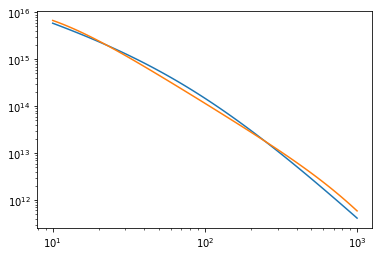

In [19]:
r=np.logspace(1,3,100)
plt.plot(r,nl.density(r))
plt.plot(r,pl.density(r))
plt.xscale('log')
plt.yscale('log')


In [20]:
ratio = sh.mr.sum()/np.float(nl.mass)
print (" %10.4e %10.4e %8.5f" %  (sh.mr.sum(),pl.mass(),ratio))


 1.8767e+14 5.2219e+15  0.18767


In [23]:
from colossus.tests import run_tests


test_get_version (colossus.tests.test_utils.TCVersions) ... ok
test_versions (colossus.tests.test_utils.TCVersions) ... ok
test_critical_density (colossus.tests.test_utils.TCConstants) ... ok
test_deltac (colossus.tests.test_utils.TCConstants) ... ok
test_gravitational_constant (colossus.tests.test_utils.TCConstants) ... ok
test_storage (colossus.tests.test_utils.TCStorageNonPersistent) ... ok
test_storage_dir (colossus.tests.test_utils.TCStorageNonPersistent) ... ok
test_storage (colossus.tests.test_utils.TCStoragePersistent) ... ok
test_storage_dir (colossus.tests.test_utils.TCStoragePersistent) ... ok
test_Ez (colossus.tests.test_cosmology.TCComp) ... ok
test_Hz (colossus.tests.test_cosmology.TCComp) ... ok
test_Ob (colossus.tests.test_cosmology.TCComp) ... ok
test_Ode (colossus.tests.test_cosmology.TCComp) ... ok
test_Ogamma (colossus.tests.test_cosmology.TCComp) ... ok
test_Ok (colossus.tests.test_cosmology.TCComp) ... ok
test_Om (colossus.tests.test_cosmology.TCComp) ... ok
test_

In [27]:
from colossus.cosmology import cosmology
cosmology.setCosmology('planck15');
from colossus.halo import mass_so

R200c = mass_so.M_to_R(1E15*0.7, 0.5, '200c')
R200c/0.7

1717.0040276600917

In [70]:
def shmf_gao(m,M200,mucut=0.1,mu1=0.01,b=1.2,a=-0.94):
    mu=m/M200
    return (mu/mu1)**a*np.exp(-(mu/mucut)**b)


masses = np.logspace(9,15,1000)
nm=shmf_gao(masses,1e15)
print (nm[0])

def generate_mass(M200, rn):
    mucut=0.1
    mu1=0.01
    b=1.2
    a=-0.94
    def shmf_gao_(m):
        
        mu=m/M200
        return (mu/mu1)**a*np.exp(-(mu/mucut)**b)/shmf_gao(np.min(masses),M200)-rn
    
    root = optimize.brentq(shmf_gao_, 1e9, 1e15)
    return root

rn_ = np.random.random_sample(np.int(nm[0]))
mgen=[]
for rn in rn_:
    mgen.append(generate_mass(1e15,rn))
print (np.array(mgen).sum(),np.array(mgen).sum()/1e15)

5754.393618975071
87424587105409.75 0.08742458710540975


[1475 1080  789  594  446  357  256  194  143  111   80   57   34   32
   24   25    9   12    8   10    5    2    1    1    3    2    2    1
    0    1]


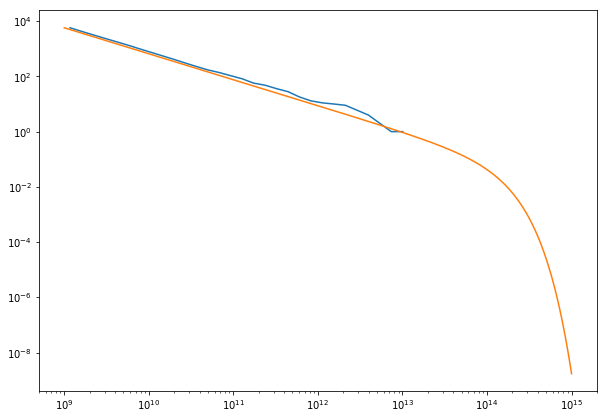

In [93]:
fig,ax=plt.subplots(1,1,figsize=(10,7))
#n, bins, patches = ax.hist(mgen, 30, histtype='step',
#                           cumulative=-1, log=True)
h,b=np.histogram(np.log10(mgen),bins=30)
print (h)
hc=[]
bb=[]
for i in range(len(b)-1):
    bb.append(0.5*(b[i]+b[i+1]))
    hc.append(np.sum(h[i:]))
bb=np.array(bb)
hc=np.array(hc)
ax.plot(10**bb,hc)
ax.plot(masses,nm)
ax.set_xscale('log')
ax.set_yscale('log')


In [91]:
h[1:]

array([1080,  789,  594,  446,  357,  256,  194,  143,  111,   80,   57,
         34,   32,   24,   25,    9,   12,    8,   10,    5,    2,    1,
          1,    3,    2,    2,    1,    0,    1])